<!-- Encabezado con dos logos -->
<table style="width:100%; border:0px">
  <tr style="border:0px">
    <td align="left" style="border:0px">
      <img src="https://www.uclm.es/images/logos/Logo_uclm_40.png" alt="Universidad" height="80">
    </td>
    <td align="right" style="border:0px">
      <img src="https://simd.i3a.uclm.es/wp-content/uploads/2025/01/LOGO-Pie-SIMD-1.webp" alt="Grupo de Investigación" height="80">
    </td>
  </tr>
</table>

<br>

<!-- Título del documento -->
<h1 align="center"> Assignment 3.- Bicycle model and PID control </h1>

<!-- Información institucional -->
<p align="center">
  <strong>Degree in Computer Science</strong>
  <br>  
  Universidad de Castilla-La Mancha  
  <br>
  <strong>Teacher:</strong> Jesús Martínez Gómez (Jesus.Martinez@uclm.es)
</p>

# Presentation

# Assignment 3: Bicycle model and PID control

This notebook is designed to prepare the homework3, to be coded in ROS2.  

The goal is to understand:

- The **bicycle kinematic model**,
- The concept of **cross-track error (CTE)**,
- The effect of **P, PD and PID** control while following a closed oval track.

The homework 3 will use **ROS2 + turtlesim**, where the controller will act on angular velocity.  

Here, instead, we use a slightly more realistic **bicycle model**, where the controller acts on the **steering angle**.

## Imports and reusable helpers **(do not modify / add new methods if needed)**

Two utility functions are defined:

- `wrap_to_pi(angle)`: keeps any angle inside the interval $[-\pi,\pi]$,
- `clamp(value, lower, upper)`: limits a value to a safe range.

These two helpers are extremely common in robotics:
- Angle wrapping avoids discontinuities when working with orientations,
- Clamping avoids asking the actuator to do something physically impossible.

In [1]:
import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np


def wrap_to_pi(angle: float) -> float:
    # Angles differing by 2*pi represent the same orientation.
    # This helper keeps the value in [-pi, pi], which is easier to interpret.
    return (angle + np.pi) % (2.0 * np.pi) - np.pi


def clamp(value: float, lower: float, upper: float) -> float:
    # Generic saturation helper.
    # In robotics, clamping is frequently used to model actuator limits.
    return max(lower, min(upper, value))

## Global parameters

### Notes
- The PID gains are intentionally kept in the range $[0,1]$ so that tuning remains intuitive.
- `STEERING_BIAS` models a **persistent actuation offset**. This is useful because it creates a systematic deviation, making the role of the integral term easier to understand.

In [2]:
# ---------------------------------------------------------------------------
# Global parameters (single visible configuration zone)
# ---------------------------------------------------------------------------

# Simulation
DT = 0.10          # integration step (seconds)
N_STEPS = 520      # number of simulation iterations
# N_STEPS = 260      # number of simulation iterations

# Bicycle model
WHEEL_BASE = 2.0
VELOCITY = 1.6
MAX_STEERING = np.deg2rad(35.0)   # actuator saturation

# Oval track geometry (similar logic to the later turtlesim homework)
TRACK_CENTER = np.array([0.0, 0.0], dtype=float)
TRACK_RADIUS = 5.0                # radius of the two semicircles
TRACK_STRAIGHT_HALF = 5.0         # half length of each straight section

# Initial state (top-left zone, facing approximately to the right)
# We intentionally start slightly away from the track so that the controller
# has to react from the very beginning.
X0 = -TRACK_RADIUS
Y0 = TRACK_RADIUS + 0.8
THETA0 = np.deg2rad(-6.0)

# Controller parameters (kept in the standard range [0, 1])
TAU_P = 0.5
TAU_D = 0.25
TAU_I = 0.125

# Numerical / robustness parameters
# The integral state is clamped to avoid excessive accumulation (windup).
INTEGRAL_CLAMP = 25.0

# Persistent actuator bias
# This models a constant steering offset in the actuator or calibration.
# Set it to 0.0 for the nominal case, or try values such as 2-4 degrees
# to understand why the integral term can be useful.
STEERING_BIAS = np.deg2rad(0)


### Bicycle model geometry

The steering command is represented by the front-wheel angle $\delta$.  

This steering angle produces a change in the vehicle heading:

$$
\text{turn} = \frac{d}{L} \tan(\delta)
$$

where $L$ is the wheelbase and $$d = v \cdot dt$$ is the distance traveled in one time step.

---

### Instantaneous Center of Rotation (ICR)

When the steering angle is not zero, the vehicle does not move in a straight line.  
Instead, it follows a circular trajectory around a point called the **Instantaneous Center of Rotation (ICR)**.

The radius of this circular motion is:

$$
R = \frac{d}{\text{turn}} = \frac{L}{\tan(\delta)}
$$

---

### Computing the ICR

Given the current position $(x, y)$ and orientation $\theta$, the center of rotation $(c_x, c_y)$ can be computed as:

$$
c_x = x - R \sin(\theta)
$$

$$
c_y = y + R \cos(\theta)
$$

This point lies perpendicular to the vehicle's heading direction and at a distance $R$ from the rear axle.

---

### Updating the pose

Once the center of rotation is known, the vehicle moves along a circular arc.

First, the new orientation is:

$$
\theta_{t+1} = \theta_t + \text{turn}
$$

Then, the new position is computed using the same circular geometry:

$$
x_{t+1} = c_x + R \sin(\theta_{t+1})
$$

$$
y_{t+1} = c_y - R \cos(\theta_{t+1})
$$

---

### Two motion cases

If the steering angle is very small, then the heading change is also very small and we use a straight-motion approximation:

$$
x_{t+1} = x_t + d \cos(\theta)
$$

$$
y_{t+1} = y_t + d \sin(\theta)
$$

Otherwise, the vehicle follows the circular motion described above.

---

### Important note

Different sources may use slightly different equations (for example, using $\cos$ instead of $\sin$, or different signs).

These differences come from different coordinate conventions and angle definitions.

What is important is to keep the formulation **internally consistent** between:
- How the center of rotation is computed, and  
- How the position is updated.

---

### Why this model?
It is still simple enough for an introductory assignment, but it is also realistic enough to highlight important robotics ideas:

- The vehicle cannot move sideways,
- Turning depends on both the steering command and the wheel base,
- The steering actuator is saturated,
- The same forward distance $d$ can lead to very different trajectories depending on the curvature induced by $\delta$.

---

### More information

[Kinematic Bicycle Model — Algorithms for Automated Driving](https://thomasfermi.github.io/Algorithms-for-Automated-Driving/Control/BicycleModel.html?utm_source=chatgpt.com)

[Simple Understanding of Kinematic Bicycle Model (Medium)](https://dingyan89.medium.com/simple-understanding-of-kinematic-bicycle-model-81cac6420357?utm_source=chatgpt.com)

In [3]:

@dataclass
class BicycleState:
    # Minimal state for the kinematic model.
    x: float
    y: float
    theta: float


class BicycleModel:
    def __init__(self, x: float, y: float, theta: float,
                 wheel_base: float = WHEEL_BASE,
                 velocity: float = VELOCITY,
                 dt: float = DT,
                 max_steering: float = MAX_STEERING,
                 tolerance: float = 1e-3):
        self.state = BicycleState(x, y, theta)
        self.wheel_base = wheel_base
        self.velocity = velocity
        self.dt = dt
        self.max_steering = max_steering
        self.tolerance = tolerance

    def step(self, steering_angle: float):
        # First, saturate the requested steering angle.
        # Even if a controller asks for a larger turn, the actuator cannot exceed
        # its physical limit.
        delta = clamp(float(steering_angle), -self.max_steering, self.max_steering)

        # Read the current state to make the update equations easier to follow.
        x, y, theta = self.state.x, self.state.y, self.state.theta
        L = self.wheel_base

        # The vehicle advances a forward distance equal to v * dt during this step.
        distance = self.velocity * self.dt

        # Geometric heading change induced by the steering angle.
        turn = math.tan(delta) * distance / L

        # If the steering is very small, the curvature is almost zero.
        # In that case, a straight-line approximation is more stable and easier
        # to interpret than computing a very large turning radius.
        if abs(turn) < self.tolerance:
            x_next = x + distance * math.cos(theta)
            y_next = y + distance * math.sin(theta)
            theta_next = wrap_to_pi(theta + turn)

        # Otherwise, use the bicycle model around the instantaneous center
        # of rotation. This makes the vehicle follow a circular arc.
        else:
            radius = distance / turn

            # Instantaneous center of rotation (ICR)
            cx = x - math.sin(theta) * radius
            cy = y + math.cos(theta) * radius

            theta_next = wrap_to_pi(theta + turn)
            x_next = cx + math.sin(theta_next) * radius
            y_next = cy - math.cos(theta_next) * radius

        # Save the new state and return it for convenience.
        self.state = BicycleState(x_next, y_next, theta_next)
        return self.state


## Bicycle model visualization **(do not modify)**

This visualization uses exactly the same motion model as the simulator.

The robot does not "rotate and then move", but follows a circular arc
defined by the steering angle.

When the steering is very small, the motion is approximated as a straight line.

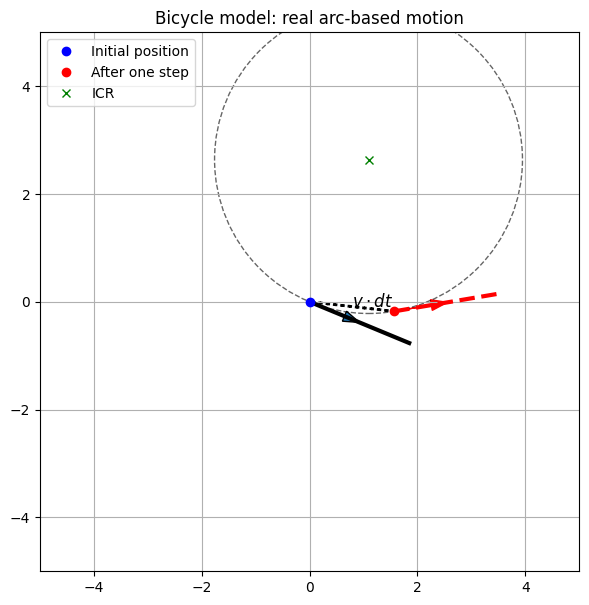

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_bicycle_step(model: BicycleModel, steering_angle: float):
    """
    Visualize one step of the BicycleModel using the SAME logic as step().

    Parameters:
    - model: instance of BicycleModel
    - delta: steering command
    """

    # --- Extract current state ---
    x = model.state.x
    y = model.state.y
    theta = model.state.theta
    L = model.wheel_base
    dt = model.dt
    v = model.velocity
    max_steering = model.max_steering
    bias = STEERING_BIAS
    tolerance = model.tolerance

    # --- Clamp steering ---
    delta = np.clip(steering_angle, -max_steering, max_steering)

    # --- Apply bias ---
    delta2 = delta + bias

    # --- Distance ---
    distance = v * dt

    # --- Compute turn ---
    turn = np.tan(delta) * distance / L

    # --- Compute next state (same logic as step) ---
    if abs(turn) < tolerance:
        # Straight approximation
        x_new = x + distance * np.cos(theta)
        y_new = y + distance * np.sin(theta)
        theta_new = theta + turn

        cx, cy, radius = None, None, None

    else:
        radius = distance / turn

        cx = x - np.sin(theta) * radius
        cy = y + np.cos(theta) * radius

        theta_new = theta + turn

        x_new = cx + np.sin(theta_new) * radius
        y_new = cy - np.cos(theta_new) * radius

    # -----------------------------
    # Plot
    # -----------------------------
    fig, ax = plt.subplots(figsize=(7, 7))

    # --- Initial vehicle ---
    rear = np.array([x, y])
    front = rear + L * np.array([np.cos(theta), np.sin(theta)])

    ax.plot([rear[0], front[0]], [rear[1], front[1]], 'k-', linewidth=3)
    ax.plot(rear[0], rear[1], 'bo', label="Initial position")

    # Orientation arrow
    ax.arrow(x, y, np.cos(theta), np.sin(theta),
             head_width=0.2, length_includes_head=True)

    # --- New vehicle ---
    rear_new = np.array([x_new, y_new])
    front_new = rear_new + L * np.array([np.cos(theta_new), np.sin(theta_new)])

    ax.plot([rear_new[0], front_new[0]], [rear_new[1], front_new[1]],
            'r--', linewidth=3)
    ax.plot(rear_new[0], rear_new[1], 'ro', label="After one step")

    # New orientation
    ax.arrow(x_new, y_new, np.cos(theta_new), np.sin(theta_new),
             head_width=0.2, length_includes_head=True, color='red')

    # --- Displacement ---
    dx = x_new - x
    dy = y_new - y

    ax.arrow(x, y, dx, dy,
             linestyle=':', linewidth=2, length_includes_head=True)

    ax.text(x + dx/2, y + dy/2, r"$v \cdot dt$", fontsize=12)

    # --- ICR and arc ---
    if radius is not None:
        ax.plot(cx, cy, 'gx', label="ICR")

        circle = plt.Circle((cx, cy), abs(radius),
                            fill=False, linestyle='--', alpha=0.6)
        ax.add_patch(circle)

    # --- Styling ---
    ax.set_aspect('equal')
    ax.grid(True)
    ax.legend()
    ax.set_title("Bicycle model: real arc-based motion")

    ax.set_xlim(x - 5, x + 5)
    ax.set_ylim(y - 5, y + 5)

    plt.show()

robot = BicycleModel(0,0,-np.pi/8, dt=1.0)
plot_bicycle_step(robot, steering_angle=np.pi/4)

## Oval track geometry and CTE computation **(do not modify)**

The reference circuit is composed of:

- An **upper straight** at $y = +r$, between $x = -r$ and $x = +r$
- A **lower straight** at $y = -r$, between $x = -r$ and $x = +r$
- A **left semicircle** centered at $(-r, 0)$
- A **right semicircle** centered at $(+r, 0)$

The key geometric quantity is the **cross-track error** (`cte`): the signed distance between the current vehicle position and the desired path.

### Sign convention used in this notebook
We will use the same idea throughout the whole track:

- **Positive CTE** means the vehicle is **outside** the circuit
- **Negative CTE** means the vehicle is **inside** the circuit

This sign convention is very important because the controller uses it to decide **which way to steer**.

In [5]:
LEFT_CENTER = np.array([-TRACK_RADIUS, 0.0], dtype=float)
RIGHT_CENTER = np.array([TRACK_RADIUS, 0.0], dtype=float)


def classify_track_region(x: float, y: float) -> str:
    # We split the track into four regions.
    # This makes the CTE computation easier and mirrors the logic that will
    # later be used in turtlesim.
    if x < -TRACK_RADIUS:
        return "left_curve"
    if x > TRACK_RADIUS:
        return "right_curve"
    if y >= 0.0:
        return "upper_straight"
    return "lower_straight"


def compute_cte(x: float, y: float) -> float:
    # Signed distance to the reference track.
    # Positive = outside the circuit
    # Negative = inside the circuit
    region = classify_track_region(x, y)

    if region == "upper_straight":
        # The reference line is y = +TRACK_RADIUS.
        # Being above that line means being outside.
        return y - TRACK_RADIUS

    if region == "lower_straight":
        # The reference line is y = -TRACK_RADIUS.
        # Being below that line means being outside.
        return (-TRACK_RADIUS) - y

    if region == "left_curve":
        # In the left curve, the reference is a semicircle centered at LEFT_CENTER.
        # The Euclidean distance to that center tells us whether we are inside
        # or outside the desired radius.
        dist = np.linalg.norm(np.array([x, y]) - LEFT_CENTER)
        return dist - TRACK_RADIUS

    # region == "right_curve"
    dist = np.linalg.norm(np.array([x, y]) - RIGHT_CENTER)
    return dist - TRACK_RADIUS


def reference_heading(region: str, x: float, y: float) -> float:
    # This function is not used by the PID itself, but it can help us interpret
    # the desired tangential direction of motion along the circuit.
    if region == "upper_straight":
        return 0.0
    if region == "lower_straight":
        return np.pi

    if region == "left_curve":
        phi = math.atan2(y - LEFT_CENTER[1], x - LEFT_CENTER[0])
        return wrap_to_pi(phi - np.pi / 2.0)

    phi = math.atan2(y - RIGHT_CENTER[1], x - RIGHT_CENTER[0])
    return wrap_to_pi(phi - np.pi / 2.0)


## Quick validation of the CTE sign convention

Before simulating the controller, it is worth checking a few hand-picked points.

This is a good robotics habit:  
when a control pipeline fails, the problem is often not in the controller itself, but in a geometric function such as the error computation.

The examples below should confirm that:
- points outside the track produce **positive** CTE,
- points inside the track produce **negative** CTE.


In [6]:
cte_examples = {
    "upper / outside": compute_cte(0.0, TRACK_RADIUS + 1.0),
    "upper / inside": compute_cte(0.0, TRACK_RADIUS - 1.0),
    "lower / outside": compute_cte(0.0, -TRACK_RADIUS - 1.0),
    "lower / inside": compute_cte(0.0, -TRACK_RADIUS + 1.0),
    "left curve / outside": compute_cte(-TRACK_RADIUS - 5.5, 0.0),
    "left curve / inside": compute_cte(-TRACK_RADIUS - 4.2, 0.0),
    "right curve / outside": compute_cte(TRACK_RADIUS + 5.5, 0.0),
    "right curve / inside": compute_cte(TRACK_RADIUS + 4.2, 0.0),
}

cte_examples


{'upper / outside': 1.0,
 'upper / inside': -1.0,
 'lower / outside': 1.0,
 'lower / inside': -1.0,
 'left curve / outside': np.float64(0.5),
 'left curve / inside': np.float64(-0.8000000000000007),
 'right curve / outside': np.float64(0.5),
 'right curve / inside': np.float64(-0.8000000000000007)}

## Controllers

We will compare four controllers:

1. **No control**: the steering angle is always zero.
2. **P**: $ \delta_t = -\tau_p \cdot cte_t $

3. **PD**: $ \delta_t = -\tau_p \cdot cte_t - \tau_d \cdot \frac{cte_t - cte_{t-1}}{\Delta t} $

4. **PID**: $ \delta_t = -\tau_p \cdot cte_t
             - \tau_d \cdot \frac{cte_t - cte_{t-1}}{\Delta t}
             - \tau_i \cdot \sum_k cte_k \Delta t $

### Interpretation
- The **P term** reacts to the current error.
- The **D term** reacts to how fast the error is changing.
- The **I term** reacts to the accumulated error over time.

In many practical situations:
- `P` is responsible for the main correction,
- `D` helps damping oscillations,
- `I` is especially useful when a **persistent bias** prevents the error from going to zero.

---

Links for additional information:

* [Autonomous Vehicles](https://av1tenth-docs.readthedocs.io/en/latest/information/theoryinfo/pid.html)
* [Video](https://www.youtube.com/watch?v=4Y7zG48uHRo)

In [ ]:
class ControllerBase:
    def reset(self):
        # Controllers with memory (PD, PID) override internal state here.
        pass

    def __call__(self, cte: float) -> float:
        raise NotImplementedError


class NullController(ControllerBase):
    def __call__(self, cte: float) -> float:
        return 0.0


class PController(ControllerBase):
    def __init__(self, tau_p: float):
        self.tau_p = tau_p

    def __call__(self, cte: float) -> float:
        return -self.tau_p * cte  # The larger the current error, the larger the correction.


class PDController(ControllerBase):
    def __init__(self, tau_p: float, tau_d: float, dt: float = DT):
        self.tau_p = tau_p
        self.tau_d = tau_d
        self.dt = dt
        self.prev_cte = None

    def reset(self):
        self.prev_cte = None

    def __call__(self, cte: float) -> float:
        # Derivative term: approximate how fast the error is changing.
        if self.prev_cte is None:
            d_cte = 0.0
        else:
            d_cte = (cte - self.prev_cte) / self.dt

        self.prev_cte = cte
        return -self.tau_p * cte - self.tau_d * d_cte


class PIDController(ControllerBase):
    def __init__(self, tau_p: float, tau_d: float, tau_i: float,
                 dt: float = DT, integral_clamp: float = INTEGRAL_CLAMP):
        self.tau_p = tau_p
        self.tau_d = tau_d
        self.tau_i = tau_i
        self.dt = dt
        self.integral_clamp = integral_clamp
        self.prev_cte = None
        self.cte_integral = 0.0

    def reset(self):
        self.prev_cte = None
        self.cte_integral = 0.0

    def __call__(self, cte: float) -> float:
        # Derivative part
        if self.prev_cte is None:
            d_cte = 0.0
        else:
            d_cte = (cte - self.prev_cte) / self.dt

        # Integral part: accumulate error over time.
        self.cte_integral += cte * self.dt

        # Anti-windup by simple clamping of the integral state.
        self.cte_integral = clamp(self.cte_integral,
                                  -self.integral_clamp,
                                  self.integral_clamp)

        self.prev_cte = cte

        return (-self.tau_p * cte
                -self.tau_d * d_cte
                -self.tau_i * self.cte_integral)

## Simulation loop **(do not modify)**

At each step we:

1. Read the current vehicle pose
2. Determine the track region
3. Compute the current CTE
4. Query the controller
5. Clamp the steering command to respect actuator limits
6. Add the optional steering bias
7. Advance the bicycle model
8. Store all relevant signals for later analysis

This structure mirrors a simplified robotics control pipeline:
**perception / geometry → control law → actuator command → motion update**.


In [8]:
def run_simulation(controller: ControllerBase,
                   n_steps: int = N_STEPS,
                   x0: float = X0,
                   y0: float = Y0,
                   theta0: float = THETA0,
                   steering_bias: float = STEERING_BIAS):
    # Create a fresh vehicle and reset the controller state.
    vehicle = BicycleModel(x0, y0, theta0)
    controller.reset()

    # History dictionary: we store all relevant signals so that they can be
    # inspected later without rerunning the simulation.
    history = {
        "x": [x0],
        "y": [y0],
        "theta": [theta0],
        "cte": [],
        "steering_cmd": [],
        "steering_applied": [],
        "region": [],
        "heading_ref": [],
        "steering_bias": steering_bias,
    }

    for _ in range(n_steps):
        # 1) Read current pose
        x = vehicle.state.x
        y = vehicle.state.y

        # 2) Geometric interpretation of the current position
        region = classify_track_region(x, y)
        cte = compute_cte(x, y)
        heading_ref = reference_heading(region, x, y)

        # 3) Ask the controller for a steering command
        steering_cmd = controller(cte)

        # 4) Respect steering limits
        steering_cmd = clamp(steering_cmd, -MAX_STEERING, MAX_STEERING)

        # 5) Add the persistent bias to simulate an imperfect actuator
        steering_applied = steering_cmd + steering_bias
        steering_applied = clamp(steering_applied, -MAX_STEERING, MAX_STEERING)

        # 6) Advance the bicycle model using the applied steering
        vehicle.step(steering_applied)

        # 7) Store everything for later analysis
        history["x"].append(vehicle.state.x)
        history["y"].append(vehicle.state.y)
        history["theta"].append(vehicle.state.theta)
        history["cte"].append(cte)
        history["steering_cmd"].append(steering_cmd)
        history["steering_applied"].append(steering_applied)
        history["region"].append(region)
        history["heading_ref"].append(heading_ref)

    # Aggregate metric: average absolute distance to the track
    history["avg_abs_cte"] = float(np.mean(np.abs(history["cte"])))
    return history


## Visualization helpers **(modify if desired/needed)**


For each run, we will visualize:
- The **trajectory** followed by the vehicle,
- The evolution of the **cross-track error**,
- The difference between the **commanded steering** and the **actually applied steering**.

The last plot is especially useful when `STEERING_BIAS` is not zero, because then the actuator does not exactly apply what the controller requested.

In [9]:
def make_track_samples(n_arc: int = 240, n_straight: int = 100):
    # Sample the four pieces of the oval track to visualize the reference path.

    # Upper straight
    xu = np.linspace(-TRACK_RADIUS, TRACK_RADIUS, n_straight)
    yu = np.full_like(xu, TRACK_RADIUS)

    # Right semicircle (top to bottom)
    ang_r = np.linspace(np.pi / 2.0, -np.pi / 2.0, n_arc)
    xr = RIGHT_CENTER[0] + TRACK_RADIUS * np.cos(ang_r)
    yr = RIGHT_CENTER[1] + TRACK_RADIUS * np.sin(ang_r)

    # Lower straight (right to left)
    xl = np.linspace(TRACK_RADIUS, -TRACK_RADIUS, n_straight)
    yl = np.full_like(xl, -TRACK_RADIUS)

    # Left semicircle (bottom to top, outer side of the track)
    ang_l = np.linspace(-np.pi / 2.0, np.pi / 2.0, n_arc)
    xlc = LEFT_CENTER[0] - TRACK_RADIUS * np.cos(ang_l)
    ylc = LEFT_CENTER[1] + TRACK_RADIUS * np.sin(ang_l)

    # Concatenate the whole closed track
    x = np.concatenate([xu, xr, xl, xlc, xu[:1]])
    y = np.concatenate([yu, yr, yl, ylc, yu[:1]])
    return x, y


def plot_run(history, title="Simulation"):
    track_x, track_y = make_track_samples()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # --------------------------------------------------
    # 1) Trajectory in the plane
    # --------------------------------------------------
    ax = axes[0]
    ax.plot(track_x, track_y, "--", label="Reference track")
    ax.plot(history["x"], history["y"], label="Vehicle trajectory")
    ax.scatter(history["x"][0], history["y"][0], marker="o", s=70, label="Start")
    ax.scatter(history["x"][-1], history["y"][-1], marker="x", s=80, label="End")
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # --------------------------------------------------
    # 2) Cross-track error over time
    # --------------------------------------------------
    ax = axes[1]
    ax.plot(history["cte"])
    ax.axhline(0.0, linestyle="--")
    ax.set_title(f"CTE (avg |cte| = {history['avg_abs_cte']:.3f})")
    ax.set_xlabel("step")
    ax.set_ylabel("cte")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-10, 10)

    # --------------------------------------------------
    # 3) Steering command vs applied steering
    # --------------------------------------------------
    ax = axes[2]
    ax.plot(history["steering_cmd"], label="Steering command")
    ax.plot(history["steering_applied"], label="Steering applied", alpha=0.85, linestyle="--")
    ax.axhline(MAX_STEERING, alpha=0.5)
    ax.axhline(-MAX_STEERING, alpha=0.5)
    ax.set_title(f"Steering signals (bias={np.rad2deg(history['steering_bias']):.2f} deg)")
    ax.set_xlabel("step")
    ax.set_ylabel("steering [rad]")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


def summarize_results(results_dict):
    print("Average absolute CTE")
    print("-" * 36)
    for name, history in results_dict.items():
        print(f"{name:>10s}: {history['avg_abs_cte']:.4f}")


## Baseline experiment: no control

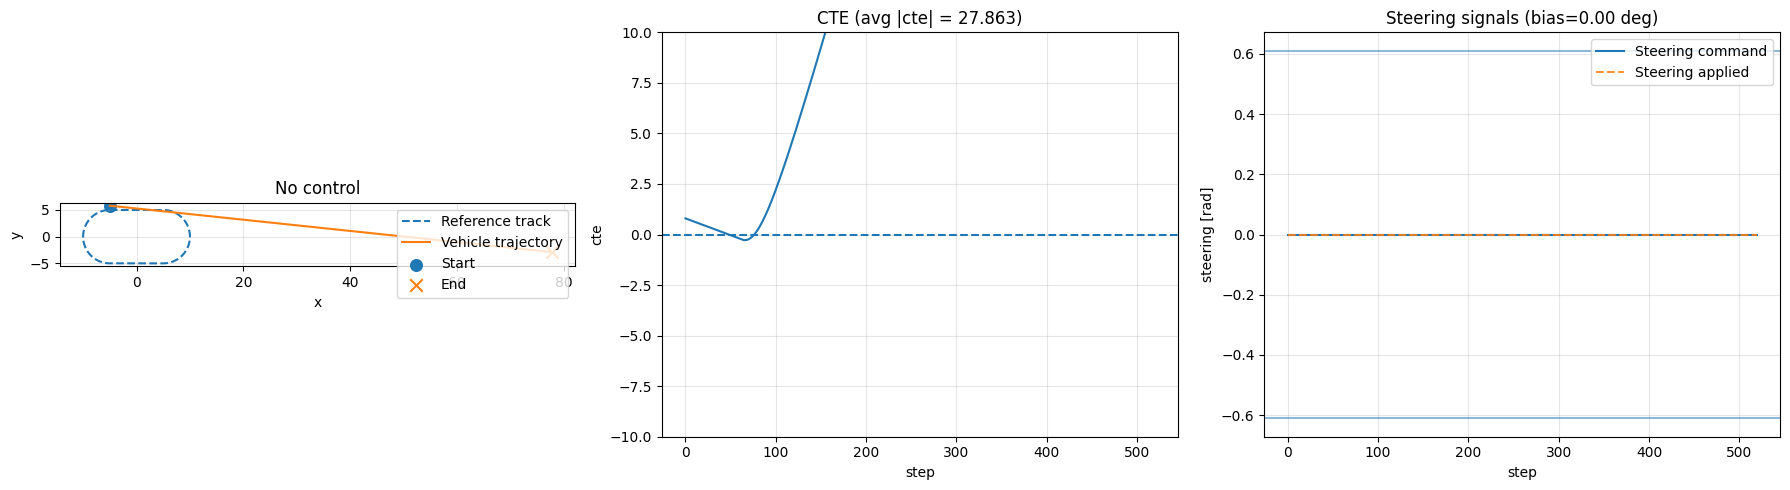

In [10]:
hist_null = run_simulation(NullController())
plot_run(hist_null, "No control")

## Experiment 1.- P controller

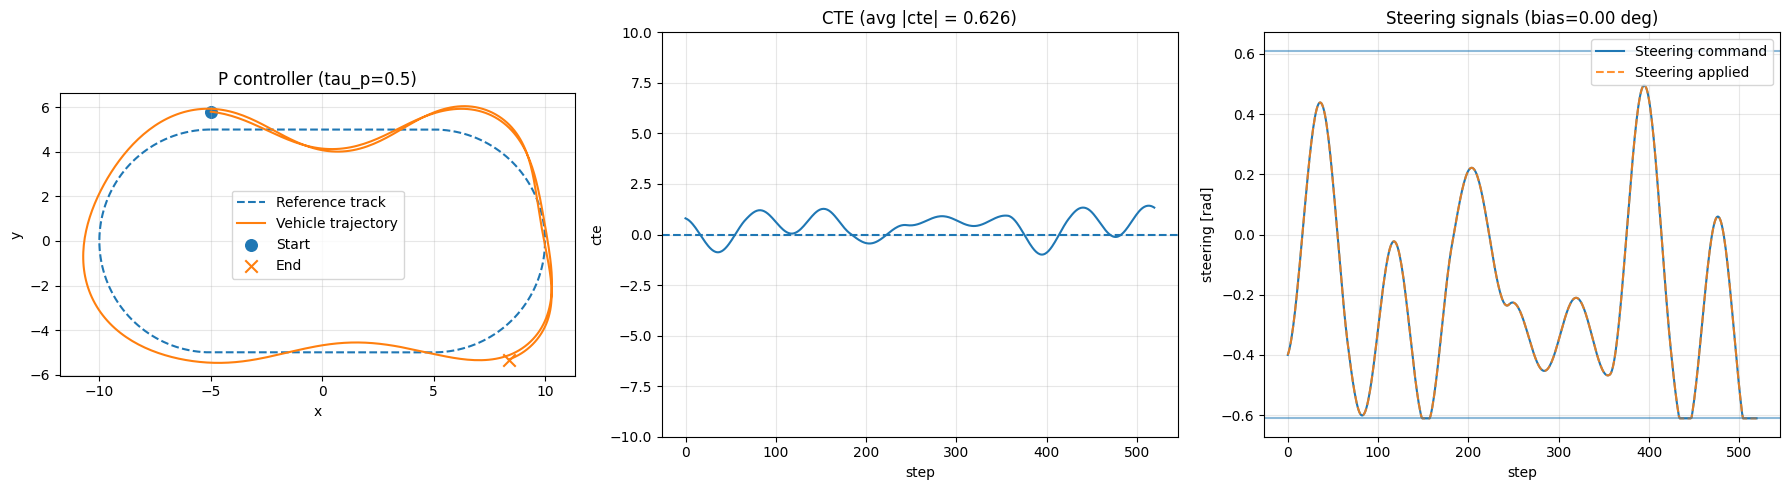

In [11]:
hist_p = run_simulation(PController(TAU_P))
plot_run(hist_p, f"P controller (tau_p={TAU_P})")

### Experiment 1 Explanation

A proportional controller is usually able to pull the vehicle back towards the track, but oscillations are common.  

Why? Because the correction only depends on the **current** error:
- If the gain is too small, the response is weak,
- If the gain is too large, the vehicle may overreact and zig-zag around the reference path.

This is one of the reasons why the derivative term is often introduced next.

## Experiment 2.- PD controller

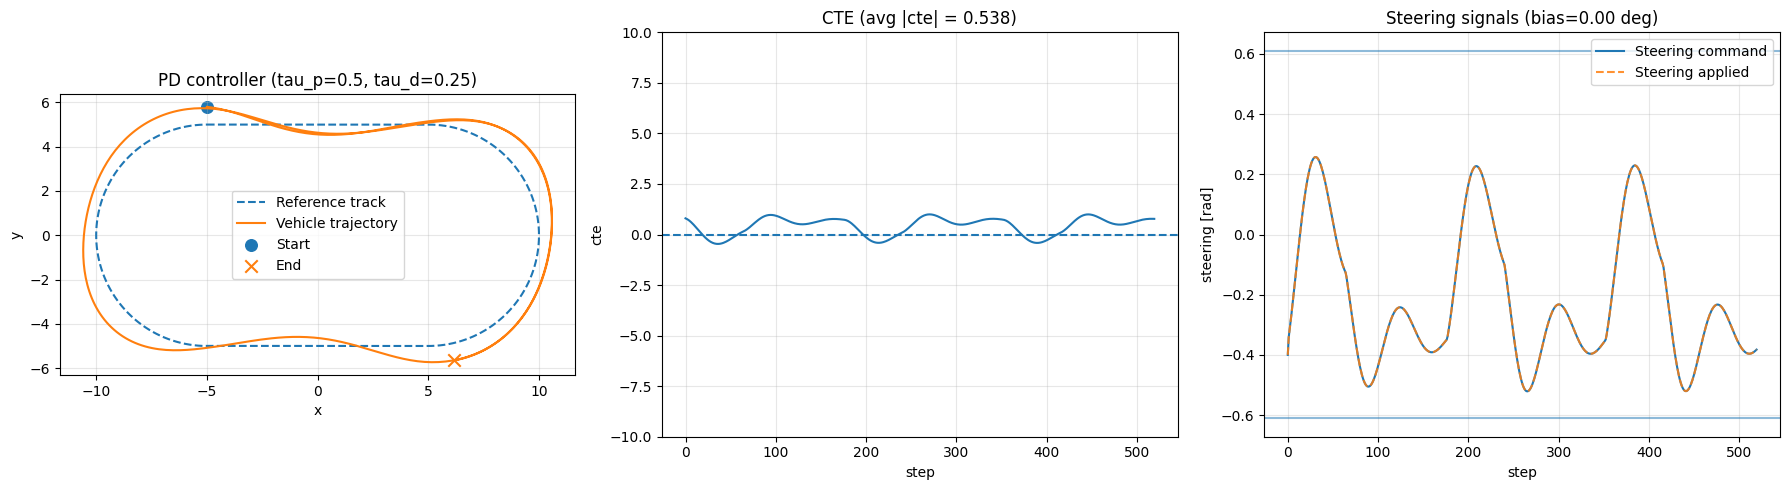

In [12]:
hist_pd = run_simulation(PDController(TAU_P, TAU_D))
plot_run(hist_pd, f"PD controller (tau_p={TAU_P}, tau_d={TAU_D})")

### Experiment 2 Explanation

The derivative term reacts to the **variation** of the error, not only to the error itself.  

Intuitively, it acts as a damping mechanism:
- When the vehicle is rapidly approaching the track, the derivative term can reduce the command
- When the vehicle is diverging, the derivative term can reinforce the correction

In practice this often reduces overshoot and improves stability.

## Experiment 2.- PID controller

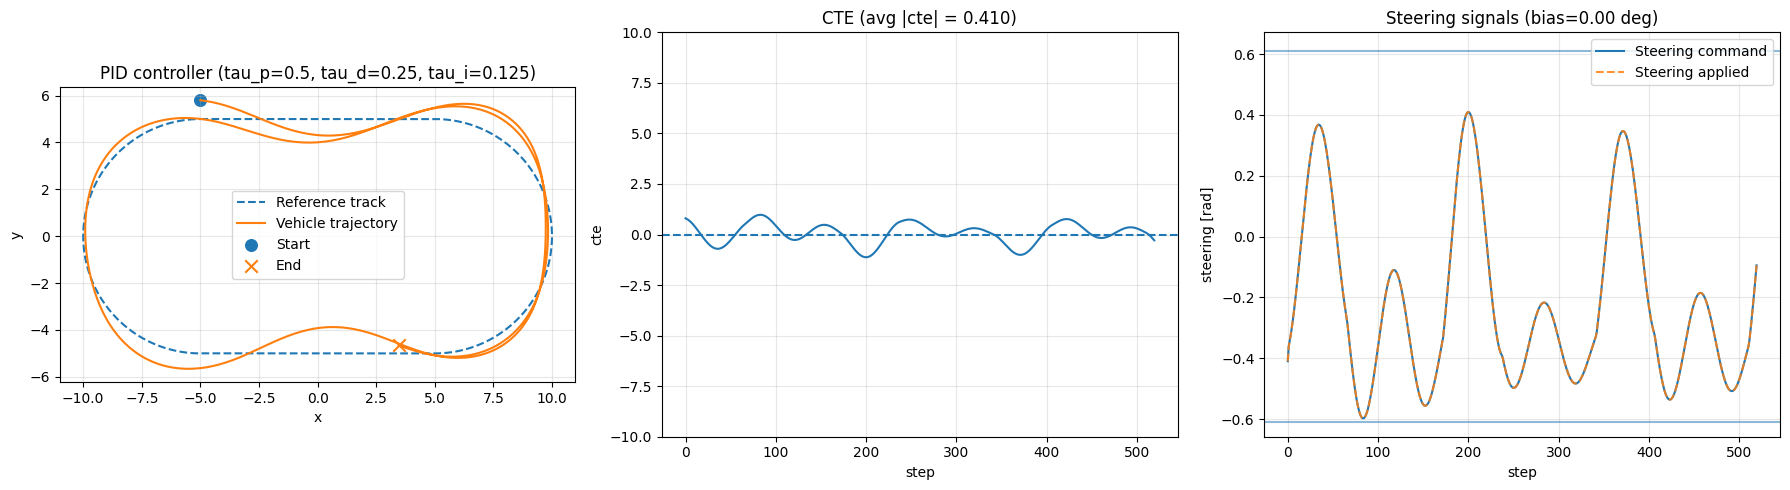

In [13]:

hist_pid = run_simulation(PIDController(TAU_P, TAU_D, TAU_I))
plot_run(hist_pid, f"PID controller (tau_p={TAU_P}, tau_d={TAU_D}, tau_i={TAU_I})")


### Experiment 3 Explanation

The integral term accumulates past errors.

This term becomes especially meaningful when the vehicle suffers from a **persistent steering bias**:
even if the proportional and derivative terms improve the trajectory, the robot may still keep a small systematic error.
By accumulating that error over time, the integral term can compensate for the offset.

However, integral action must be used with care:
- Too little integral gain may have almost no visible effect
- Too much integral gain may produce overshoot or slow oscillations
- Without protection, the accumulated error may grow excessively (**integral windup**).

For that reason, the implementation below includes a simple clamp on the integral state.

## Experiments comparison

The table below summarizes the average absolute cross-track error for each controller.

This metric is not the only possible quality measure, but it is a very convenient first indicator: smaller values usually mean that the vehicle stayed closer to the desired path on average.


In [14]:
summarize_results({
    "Baseline": hist_null,
    "Exp 1.-P": hist_p,
    "Exp 2.-PD": hist_pd,
    "Exp 3.-PID": hist_pid,
})


Average absolute CTE
------------------------------------
  Baseline: 27.8630
  Exp 1.-P: 0.6261
 Exp 2.-PD: 0.5383
Exp 3.-PID: 0.4095


## Suggested experiments for self-study

Try any of the following:

1. Set `STEERING_BIAS = np.deg2rad(3.0)` and compare **PD** versus **PID**.
2. Increase `TAU_P` and observe when oscillations become too large.
3. Reduce `TAU_D` and analyse how damping changes.
4. Increase `TAU_I` too much and observe how the controller may become unstable.

### Recommendation
Do not change many things at once.  
A better methodology is:
1. Modify a single parameter
2. Run the simulation
3. Inspect the plots

## Extra section: simple gain search with a GRASP-like strategy

The goal of this section is to show that the PID gains can also be tuned automatically with a very simple combinatorial optimization strategy.

The idea is lightweight:

1. Generate a random pool of PID candidates in the range $[0,1]$
2. Keep a small restricted candidate list with the best ones
3. Select one promising candidate
4. Apply a simple greedy local search around it
5. Keep the best result found so far

This is **not** meant to replace proper control design.  
Its purpose is pedagogical:
- To illustrate that gain tuning can be posed as an optimization problem
- To provide a simple automated baseline
- To keep the extra section self-contained and separate from the previous cells

Best gains found:
tau_p = 1.000
tau_d = 0.983
tau_i = 0.905
avg |cte| = 0.1250


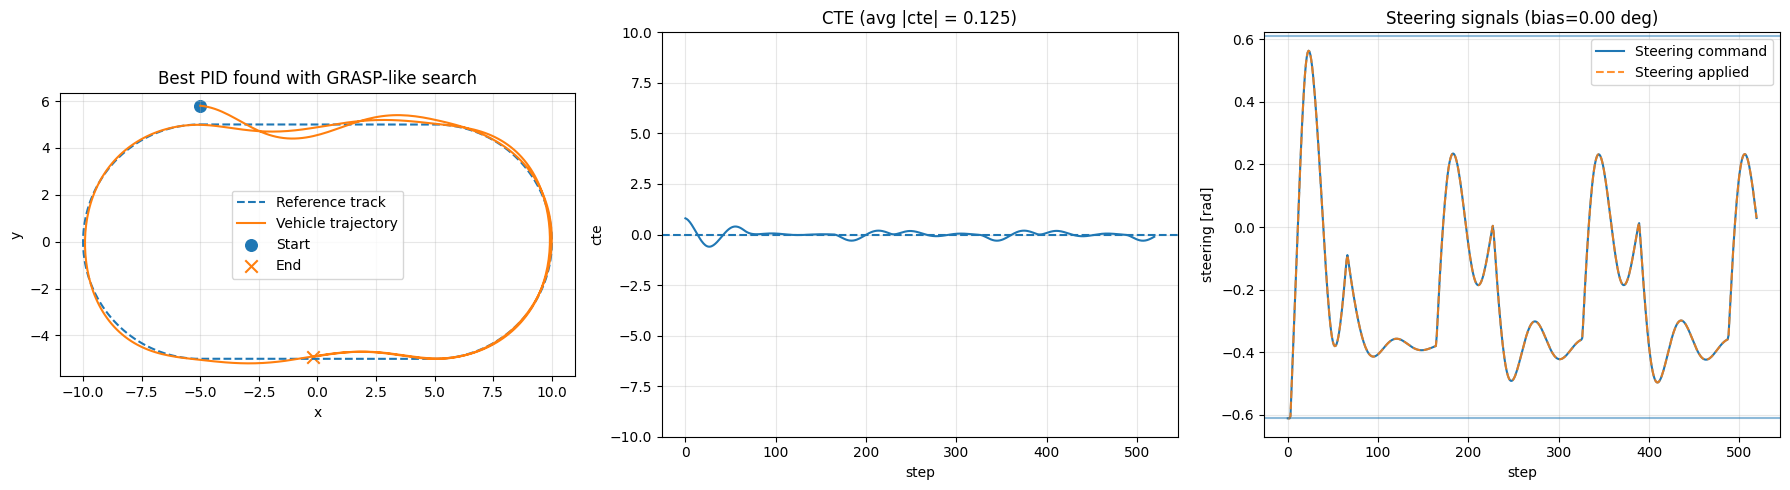

In [15]:
def evaluate_pid_gains(tau_p, tau_d, tau_i, n_steps=N_STEPS, steering_bias=STEERING_BIAS):
    # Helper used by the search procedure: lower score is better.
    controller = PIDController(tau_p, tau_d, tau_i)
    history = run_simulation(controller, n_steps=n_steps, steering_bias=steering_bias)
    return history["avg_abs_cte"], history


def grasp_like_pid_search(iterations=12,
                          candidate_pool=24,
                          elite_size=5,
                          local_trials=12,
                          step_size=0.08,
                          steering_bias=STEERING_BIAS):
    # Very lightweight GRASP-like procedure:
    # 1) create many random candidates,
    # 2) keep the best few (restricted candidate list),
    # 3) pick one promising solution,
    # 4) improve it with random local perturbations.
    best = None

    for _ in range(iterations):
        # Construction phase: random candidates in [0, 1]
        candidates = []
        for _ in range(candidate_pool):
            gains = np.random.uniform(0.0, 1.0, size=3)
            score, _ = evaluate_pid_gains(*gains, steering_bias=steering_bias)
            candidates.append((score, gains))

        # Sort candidates from best to worst according to avg_abs_cte.
        candidates.sort(key=lambda item: item[0])

        # Restricted candidate list (RCL): keep only a few promising options.
        rcl = candidates[:elite_size]
        score, gains = rcl[np.random.randint(len(rcl))]
        current_score = score
        current_gains = gains.copy()

        # Greedy local improvement around the chosen candidate
        for _ in range(local_trials):
            proposal = current_gains + np.random.uniform(-step_size, step_size, size=3)
            proposal = np.clip(proposal, 0.0, 1.0)
            proposal_score, _ = evaluate_pid_gains(*proposal, steering_bias=steering_bias)

            if proposal_score < current_score:
                current_score = proposal_score
                current_gains = proposal

        if best is None or current_score < best[0]:
            best = (current_score, current_gains)

    best_score, best_gains = best
    best_score, best_history = evaluate_pid_gains(*best_gains, steering_bias=steering_bias)
    return best_score, best_gains, best_history


best_score, best_gains, best_history = grasp_like_pid_search(
    iterations=10,
    candidate_pool=20,
    elite_size=4,
    local_trials=10,
    step_size=0.06,
    steering_bias=STEERING_BIAS,
)

print("Best gains found:")
print(f"tau_p = {best_gains[0]:.3f}")
print(f"tau_d = {best_gains[1]:.3f}")
print(f"tau_i = {best_gains[2]:.3f}")
print(f"avg |cte| = {best_score:.4f}")

plot_run(best_history, "Best PID found with GRASP-like search")
